
# **TC5033.10**
# Advanced Machine Learning Methods

## Activity 1b
### Implementing a Fully Connected Network for Kaggle ASL

## Lead Professor
José Antonio Cantoral Ceballos

## Assistant professor
Yetnalezi Quintas Ruiz

## Team 8
* Juan Felipe Caro Valencia -                   A01796224
* Ada Jimena Vargas Aguirre   -                 A01701619
* Irving Morales Cedeño -                       A01796208
* Marco Polo Navarrete Rodríguez -              A01796238
---


# TC 5033
## Deep Learning
## Fully Connected Deep Neural Networks

#### Activity 1b: Implementing a Fully Connected Network for Kaggle ASL Dataset

- Objective

The aim of this part of the activity is to apply your understanding of Fully Connected Networks by implementing a multilayer network for the [Kaggle ASL (American Sign Language) dataset](https://www.kaggle.com/datasets/grassknoted/asl-alphabet). While you have been provided with a complete solution for a Fully Connected Network using Numpy for the MNIST dataset, you are encouraged to try to come up with the solution.

- Instructions

    This activity requires submission in teams of 3 or 4 members. Submissions from smaller or larger teams will not be accepted unless prior approval has been granted (only due to exceptional circumstances). While teamwork is encouraged, each member is expected to contribute individually to the assignment. The final submission should feature the best arguments and solutions from each team member. Only one person per team needs to submit the completed work, but it is imperative that the names of all team members are listed in a Markdown cell at the very beginning of the notebook (either the first or second cell). Failure to include all team member names will result in the grade being awarded solely to the individual who submitted the assignment, with zero points given to other team members (no exceptions will be made to this rule).

    Load and Preprocess Data: You are provided a starter code to load the data. Be sure to understand the code.

    Review MNIST Notebook (Optional): Before diving into this activity, you have the option to revisit the MNIST example to refresh your understanding of how to build a Fully Connected Network using Numpy.

    Start Fresh: Although you can refer to the MNIST solution at any point, try to implement the network for the ASL dataset on your own. This will reinforce your learning and understanding of the architecture and mathematics involved.

    Implement Forward and Backward Pass: Write the code to perform the forward and backward passes, keeping in mind the specific challenges and characteristics of the ASL dataset.
    
     Design the Network: Create the architecture of the Fully Connected Network tailored for the ASL dataset. Choose the number of hidden layers, neurons, and hyperparameters judiciously.

    Train the Model: Execute the training loop, ensuring to track performance metrics such as loss and accuracy.

    Analyze and Document: Use Markdown cells to document in detail the choices you made in terms of architecture and hyperparameters, you may use figures, equations, etc to aid in your explanations. Include any metrics that help justify these choices and discuss the model's performance.  

- Evaluation Criteria

    - Code Readability and Comments
    - Appropriateness of chosen architecture and hyperparameters for the ASL dataset
    - Performance of the model on the ASL dataset (at least 70% acc)
    - Quality of Markdown documentation

- Submission

Submit this Jupyter Notebook in canvas with your complete solution, ensuring your code is well-commented and includes Markdown cells that explain your design choices, results, and any challenges you encountered.


In [32]:
# Let's get all the necessary tools ready! We're bringing in standard libraries like numpy for numerical operations,
# string for text handling, pandas for data manipulation, matplotlib for plotting lovely graphs,
# cv2 for image processing, and os/glob for interacting with our file system.
# Also, %matplotlib inline is a magic command for Jupyter to display plots right here in the notebook.
#Uncomment if you are using TPU
#!pip install opencv-python
import numpy as np
import string
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import os
from google.colab import files
import os, glob

%matplotlib inline

In [33]:
# Time to get our data from Kaggle! First, we need to upload our Kaggle API key to authenticate.
# Then, we'll create a directory for Kaggle, copy the key there, and set the right permissions.
# After that, we can download the specified dataset and unzip it into a new folder for easy access.
files.upload()

# Let's set up the Kaggle environment and get our credentials in place.
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Now, let's download the ASL dataset and unpack it.
!kaggle datasets download -d datamunge/sign-language-mnist
!unzip sign-language-mnist.zip -d sign-language-mnist

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
sign-language-mnist.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  sign-language-mnist.zip
replace sign-language-mnist/amer_sign2.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: sign-language-mnist/amer_sign2.png  
  inflating: sign-language-mnist/amer_sign3.png  
  inflating: sign-language-mnist/american_sign_language.PNG  
  inflating: sign-language-mnist/sign_mnist_test.csv  
  inflating: sign-language-mnist/sign_mnist_test/sign_mnist_test.csv  
  inflating: sign-language-mnist/sign_mnist_train.csv  
  inflating: sign-language-mnist/sign_mnist_train/sign_mnist_train.csv  


In [34]:
# We're going to load our training and validation data from the CSV files into pandas DataFrames.
# This makes it super easy to work with the data in a structured way.
DATA_PATH = 'sign-language-mnist/'
train_df = pd.read_csv(os.path.join(DATA_PATH, 'sign_mnist_train.csv'))
valid_df = pd.read_csv(os.path.join(DATA_PATH, 'sign_mnist_test.csv'))

In [35]:
# Just taking a peek at the first few rows of our training DataFrame.
# This helps us understand the structure and content of our data at a glance.
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


### Importar Images

In [36]:
# Let's separate the labels (what we want to predict) from the actual image pixel data.
# We'll put the labels into `y_train` and `y_val` arrays, and then remove the 'label' column
# from our DataFrames to get just the pixel features, which will go into `x_train` and `x_val`.
y_train = np.array(train_df['label'])
y_val = np.array(valid_df['label'])
# We're done with the 'label' column in the dataframes, so let's remove it.
del train_df['label']
del valid_df['label']
# Convert the remaining pixel data to a numpy array of float32 type for numerical stability.
x_train = train_df.values.astype(np.float32)
x_val = valid_df.values.astype(np.float32)

In [37]:
# Checking the dimensions of our validation features. This tells us how many samples and features (pixels) we have.
x_val.shape

(7172, 784)

In [38]:
# Let's see how many samples are in our validation set.
len(x_val)

7172

In [39]:
# This function helps us split our data into validation and test sets.
# It can shuffle the data and then divide it based on a specified percentage.
def split_val_test(x, y, pct=0.5, shuffle=True):
    # Calculate the split point based on the percentage.
    particion = int(len(x) * pct)
    n = len(x)

    # If shuffling is enabled, we'll randomize the order of our data.
    if shuffle:
        idx = np.random.permutation(n)
        x = x[idx]
        y = y[idx]

    # The first part becomes our validation set.
    x_test = x[particion:].astype(np.float32)
    y_test = y[particion:]

    # The second part becomes our test set.
    x_val = x[:particion].astype(np.float32)
    y_val = y[:particion]
    return x_val, y_val, x_test, y_test

In [40]:
# Now, we're taking our initial `x_val` and `y_val` and splitting them further.
# This creates separate validation and test sets as defined by our function.
x_val, y_val, x_test, y_test = split_val_test(x_val, y_val)

In [41]:
# We're preparing a list of letters for our ASL alphabet, excluding 'j' and 'z'.
# This is because 'j' and 'z' typically involve motion and are not static hand gestures in ASL.
alphabet=list(string.ascii_lowercase)
alphabet.remove('j')
alphabet.remove('z')
# Let's print the length to confirm how many classes we're working with.
print(len(alphabet))

24


### Normalise

We normalise because:
* It accelerates the training model
* It improves numeric stability
* It is required as input for most algorithms

In [42]:
# This function applies Z-Score normalization to our data.
# Normalization is crucial for machine learning models as it helps them converge faster and perform better.
def normalise (x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

# First, we calculate the mean and standard deviation from our training data.
# It's important to use the training data's statistics for consistency across all datasets.
x_mean = x_train.mean()
x_std = x_train.std()

# Now, apply the normalization to our training, validation, and test datasets.
x_train = normalise(x_mean, x_std, x_train)
x_val = normalise(x_mean, x_std, x_val)
x_test = normalise(x_mean, x_std, x_test)

# Let's quickly verify that our training data now has a mean close to 0 and a standard deviation close to 1.
x_train.mean(), x_train.std()

(np.float32(3.6268384e-06), np.float32(0.99999946))

### Graficar muestras

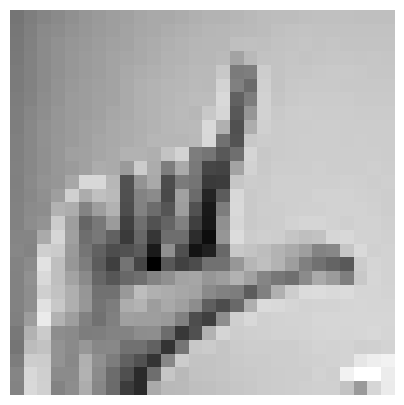

11


In [43]:
# This function is a handy utility to visualize our ASL images.
# It reshapes the 1D pixel data back into a 28x28 image and displays it in grayscale.
def plot_number(image):
  plt.figure(figsize=(5,5))
  # We need to reshape the flat pixel array into a 28x28 square for proper image display.
  plt.imshow(image.reshape(28, 28), cmap ='gray')
  # Turning off the axis makes the image cleaner.
  plt.axis('off')
  plt.show()

# Let's pick a random image from our test set to see what it looks like.
rnd_idx = np.random.randint(len(y_test))
plot_number(x_test[rnd_idx])
# And print its corresponding label to know what sign it represents.
print(y_test[rnd_idx])

### Ecuaciones para nuestro modelo


$$z^1 = W^1 X + b^1$$

$$a^1 = ReLU(z^1) $$

$$z^2 = W^2 a^1 + b^2$$

$$\hat{y} = \frac{e^{z^{2_k}}}{\sum_j{e^{z_j}}}$$


$$ \mathcal{L}(\hat{y}^{i}, y^{i}) =  - y^{i}  \ln(\hat{y}^{i}) = -\ln(\hat{y}^i)$$


$$ \mathcal{J}(w, b) =  \frac{1}{num\_samples} \sum_{i=1}^{num\_samples}-\ln(\hat{y}^{i})$$

### Funciones adicionales

#### Mini batches

The following code creates mini batches from a larger dataset to:
* Train dataset more efficiently.
* Improve convergence by adding a little noise.
* Save memory by producing data only when necessary.

In [44]:
# This function is designed to generate mini-batches from our dataset.
# Mini-batches are crucial for efficient training, especially with large datasets.
# They also introduce a bit of noise, which can help with convergence, and save memory.
def create_minibatches(mb_size,x,y,shuffle=True):
  # A quick check to ensure our features and labels have the same number of samples.
  assert x.shape[0] == y.shape[0], "Error en cantidad de muestras"
  total_data = x.shape[0]
  # If shuffling is true, we'll randomize the order of our data for better training.
  if shuffle:
    idxs = np.arange(total_data)
    np.random.shuffle(idxs)
    x=x[idxs]
    y=y[idxs]
  # This generator yields mini-batches of the specified size.
  # It iterates through the dataset, splitting it into smaller chunks.
  return ((x[i:i+mb_size],y[i:i+mb_size]) for i in range(0,total_data,mb_size))

In [45]:
# We're defining a custom NumPy tensor class. This is a clever way to extend NumPy arrays
# so we can attach additional attributes, like gradients, which are essential for backpropagation.
class np_tensor(np.ndarray): pass

## Nuestra clase Linear, ReLU y Sequential

###  Clase Linear

The following class implements a fully conected lineal layer. It also defines how to calculate gradient for backprogapation.
* Adds a dense layer.
* Implements backprogagation.


In [46]:
# This 'linear' class represents a single fully connected layer in our neural network.
# It handles the forward pass (matrix multiplication and bias addition) and the backward pass
# for calculating gradients of weights and biases.
class linear():
  # The constructor initializes the weights (W) and biases (b) for the layer.
  # Weights are initialized using a He initialization strategy, which is good for ReLU activations,
  # and biases are set to zeros. We also convert them to our custom np_tensor type.
  def __init__(self,input_size,output_size):
    self.W = (np.random.randn(output_size, input_size) / np.sqrt(input_size/2)).view(np_tensor)
    self.b = (np.zeros((output_size,1))).view(np_tensor)

  # The __call__ method defines the forward pass: Z = WX + b.
  # It allows us to treat an instance of the class like a function.
  def __call__(self, X):
     Z = self.W @ X + self.b
     return Z

  # The backward method calculates the gradients for the weights, biases, and the input.
  # This is a crucial step for updating our model's parameters during training.
  def backward(self,X,Z):
    X.grad = self.W.T @ Z.grad
    self.W.grad = Z.grad @ X.T
    self.b.grad = Z.grad.sum(axis=1, keepdims=True)

### Clase ReLU

The following class implements activacion function ReLU for forward and backward pass. It's the maximum between 0 and z.
* Introduces nonlinearity.
* Improves training.
* Integrates with backward function of linear class

In [47]:
# This 'ReLU' class implements the Rectified Linear Unit activation function.
# ReLU introduces non-linearity into our network, allowing it to learn complex patterns.
# It's simple: any negative input becomes zero, positive inputs pass through unchanged.
class ReLU():
  # The __call__ method performs the ReLU activation: max(0, Z).
  def __call__(self,Z):
    return np.maximum(0,Z)

  # The backward method calculates the gradient for ReLU.
  # The gradient is 1 for positive inputs and 0 for negative/zero inputs.
  def backward(self,Z,A):
    Z.grad = A.grad.copy()
    Z.grad[Z <= 0] = 0

### Clase Sequential

This class integrates the previous classes. It implements a sequential model:
* Automatic Forward.
* Backpropagation.
* Setting of parameters.
* Optimization.
* Prediction.

In [48]:
# The 'sequential_layers' class brings everything together to build our neural network model.
# It chains together linear layers and activation functions (like ReLU) in a sequence.
class sequential_layers():
  # The constructor takes a list of layers (e.g., linear, ReLU) and initializes them.
  def __init__(self,layers):
    self.layers = layers
    self.x = None
    # This dictionary will store the outputs of each layer, which we'll need for backpropagation.
    self.outputs = {}

  # The __call__ method defines the full forward pass through the entire network.
  # It iterates through each layer, passing the output of one as the input to the next.
  def __call__(self,X):
    self.x = X
    # We store the initial input 'X' as the output of a 'layer 0'.
    self.outputs['l0']=self.x
    # Loop through each defined layer, performing its forward pass.
    for i,layer in enumerate(self.layers,1):
      self.x = layer(self.x)
      self.outputs['l'+str(i)]=self.x
    return self.x

  # The backward method orchestrates the backpropagation process.
  # It goes through the layers in reverse order, calling each layer's backward method.
  def backward(self):
    # Iterate backwards from the last layer to the first.
    for i in reversed(range(len(self.layers))):
      # We pass the input and output of the current layer to its backward method.
      self.layers[i].backward(self.outputs['l'+str(i)],self.outputs['l'+str(i+1)])

  # The update method adjusts the model's weights and biases using gradient descent.
  # It uses the calculated gradients and a learning rate to take small steps towards optimization.
  def update(self,learning_rate=1e-3):
    # We only update layers that have trainable parameters (like linear layers, not ReLU).
    for layer in self.layers:
      if isinstance(layer,ReLU): continue
      # Update weights and biases by subtracting a fraction of their gradients.
      layer.W = layer.W - learning_rate * layer.W.grad
      layer.b = layer.b - learning_rate * layer.b.grad

  # The predict method performs a forward pass and returns the most likely class prediction.
  def predict(self,X):
    # It gets the raw scores from the network and then takes the index of the maximum score.
    return np.argmax(self.__call__(X))

### Cost Function

The following function combines Softmax + Cross-Entropy and calculates gradient for backpropagation.
* Calculates loss in the clasification.
* Combines softmax + loss funcion (cross entropy)

In [49]:
# This function calculates the Softmax cross-entropy loss, which is commonly used for multi-class classification.
# It also computes the gradients needed for backpropagation.
def softmaxXEntropy(x,y):
  batch_size = x.shape[1]
  # First, we calculate the exponentiated scores to ensure positive values.
  exp_scores = np.exp(x)
  # Then, we normalize these scores to get probabilities that sum to 1.
  probs = exp_scores / exp_scores.sum(axis = 0)
  # We keep a copy of the probabilities for prediction purposes.
  preds = probs.copy()

  # --- Calculating the Cost (Loss) ---
  # We extract the predicted probability for the *true* class for each sample in the batch.
  y_hat = probs[y.squeeze(),np.arange(batch_size)]
  # The cross-entropy loss is calculated as the negative log of these probabilities, averaged over the batch.
  # This heavily penalizes confident wrong predictions.
  cost = np.sum(-np.log(y_hat))/batch_size

  # --- Calculating Gradients ---
  # This is a clever trick: the gradient of the softmax cross-entropy loss with respect to the input scores (x)
  # is simply the predicted probabilities minus 1 for the true class, and just the probabilities for other classes.
  probs[y.squeeze(),np.arange(batch_size)] -=1
  # We store this gradient in x.grad for backpropagation.
  x.grad = probs.copy()
  return preds, cost

### Loop de entrenamiento

The following functions create the loops for training the model and calculating the accuracy.

In [71]:
from numpy.random.mtrand import f
# This 'train' function defines our main training loop for the neural network.
# It iterates over epochs, processes data in mini-batches, performs forward and backward passes,
# and updates the model's parameters.
def train(model, epochs = 20,mb_size = 128,learning_rate=1e-3):
  # Loop through each epoch, which represents one full pass over the entire training dataset.
  faccuracy = 0
  for epoch in range(epochs):
    # Iterate through mini-batches of training data.
    for i, (x,y) in enumerate(create_minibatches(mb_size,x_train,y_train)):
      # Perform a forward pass to get the model's scores (raw predictions).
      scores = model(x.T.copy().view(np_tensor))
      # Calculate the loss and the gradients using our softmax cross-entropy function.
      _,cost = softmaxXEntropy(scores,y)
      # Execute the backward pass to compute gradients for all layers.
      model.backward()
      # Update the model's weights and biases based on the calculated gradients.
      model.update(learning_rate)

    if accuracy(x_val,y_val,mb_size) > faccuracy :
     print(f'Epoch {epoch}/{epochs} Cost: {cost}, Accuracy: {accuracy(x_val,y_val,mb_size)}')
     fepoch=epoch
     fcost=cost
     faccuracy=accuracy(x_val,y_val,mb_size)
     fmb_size=mb_size
     flearning_rate=learning_rate
  # After training, print the final cost and the accuracy on the validation set.
  print(f'Final Cost: {cost}, Accuracy: {accuracy(x_val,y_val,mb_size)}')
  print(f'Best Result Cost: {fcost}, Accuracy: {faccuracy} mb_size: {mb_size} Epoch: {fepoch} Learning_rate: {flearning_rate}')

# This 'accuracy' function evaluates the model's performance on a given dataset.
# It calculates the percentage of correctly classified samples.
def accuracy(x,y,mb_size):
  correct = 0
  total = 0
  # Iterate through the data in mini-batches.
  for i, (x,y) in enumerate(create_minibatches(mb_size,x,y)):
    # Get the model's raw predictions for the current batch.
    pred_scores = model(x.T.copy().view(np_tensor))
    # Determine the predicted class by finding the index of the highest score.
    # Then, compare these predictions to the true labels and count correct ones.
    correct += np.sum(np.argmax(pred_scores,axis=0) == y.squeeze())
    # Keep track of the total number of samples processed.
    total += pred_scores.shape[1]
  # Return the accuracy as a percentage of correct predictions.
  return correct/total

### Create your model and train it

We run 2 sets of parameters:

* Model A: 3 hidden layers, 300-200 neurons.
* Model B: 1 hidden layer, 100 neurons.

* Model A results: cost: 0.0003839060498915225, accuracy: 0. 0.8156720580033463
* Model B results: cost: 0.0021452100900369113, accuracy: 0.7844394868934746

Model B seems underfitting while model A has a better accuracy.
In model A we have a lower cost. It learned from real patterns, it distinguishes correctly between gestures, but could still get confused with similar ones.

In addition to this, the selection of Model A' architecture is justified by its complexity and hierarchical learning capabilities. Since Model A has more neurons and layers than Model B, it is able to find a mapping function that fits the data more accurately.

Meanwhile, Model B is limited and, because of the lack of enough parameters, it cannot learn the underlying patterns, thus it leads to underfitting as previously mentioned.

Furthermore, the fact that Model A has more layers allows it to "break down" the hand gestures: in the inital layer it learns the basic features, while the middle and final layers combine these patterns to develop a better understanding of abstract knowledge, resulting in better classification .



In [64]:
# Here, we're defining the architecture of our neural network.
# We're using the 'sequential_layers' class to stack several 'linear' layers interleaved with 'ReLU' activations.
# This specific model (Model A) has an input layer of 784 neurons (for a 28x28 image),
# followed by a hidden layer of 300 neurons, another hidden layer of 200 neurons, and finally
# an output layer of 24 neurons, corresponding to the 24 ASL classes.
model = sequential_layers([linear(784, 300), ReLU(), linear(300, 200), ReLU(), linear(200, 24)])
# Setting the mini-batch size for training.
mb_size = 512
# Defining the learning rate, which controls how big of a step we take during gradient descent.
learning_rate = 5e-4
# Specifying the number of epochs (how many times we'll go through the entire dataset).
epochs = 20
np.random.seed(42)

In [52]:
# Let's find out what unique labels (classes) are present in our training data.
# This helps us understand the range of signs our model needs to learn.
np.unique(y_train)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [53]:
# Our original labels might have gaps (e.g., no 'j' or 'z'). To make them contiguous (0, 1, 2...),
# we're creating a new mapping for the labels. This is important for tasks like one-hot encoding or when using
# certain loss functions that expect sequential class indices.
# First, identify the unique labels that actually exist.
labels_new = np.unique(y_train)

# Create a dictionary to map the old, possibly sparse, labels to new, contiguous indices.
label_map = {old:i for i, old in enumerate(labels_new)}

# Apply this mapping to our training, validation, and test labels.
# Now, all labels will be sequential integers from 0 to 23.
y_train = np.array([label_map[y] for y in y_train])
y_val   = np.array([label_map[y] for y in y_val])
y_test  = np.array([label_map[y] for y in y_test])

In [72]:
# Now, let's kick off the training process! We're passing our model, the number of epochs,
# batch size, and learning rate to the 'train' function. This will start the iterative learning process.
train(model, epochs, mb_size, learning_rate)

Epoch 0/20 Cost: 0.0005505323676223703, Accuracy: 0.8139988845510318
Epoch 3/20 Cost: 0.0005256351007896601, Accuracy: 0.814835471277189
Epoch 5/20 Cost: 0.0004981746558514696, Accuracy: 0.8151143335192415
Epoch 13/20 Cost: 0.0004581823263416273, Accuracy: 0.8156720580033463
Final Cost: 0.00037876438610157424, Accuracy: 0.8156720580033463
Best Result Cost: 0.0004581823263416273, Accuracy: 0.8156720580033463 mb_size: 512 Epoch: 13 Learning_rate: 0.0005


### Test your model on Random data from your test set

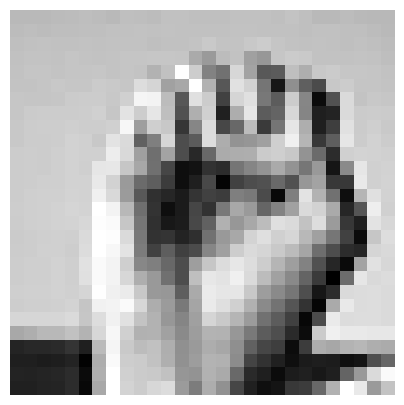

el valor predicho es: e el valor real es:e


In [73]:
# Let's randomly pick an image from our test set to see how well our trained model performs on unseen data.
# First, we select a random index.
idx = np.random.randint(len(y_test))
# Then, we display the image using our helper function.
plot_number(x_test[idx].reshape(28,28))
# We ask the model to predict the sign for this chosen image.
# Note: x_test[idx] is a 1D array, so we reshape it to (-1, 1) to make it a column vector,
# which is the expected input format for our model's forward pass.
pred = model.predict(x_test[idx].reshape(-1, 1))
# Finally, we print out the model's prediction and compare it with the actual (ground truth) label.
# We use our 'alphabet' list to convert the numerical labels back into their letter representation.
print(f'el valor predicho es: {alphabet[pred]} el valor real es:{alphabet[y_test[idx]]}')

In [57]:
# This is an empty cell, sometimes useful as a placeholder or for future additions.